In [42]:
import control as ctrl
import matplotlib.pyplot as plt
import numpy as np

In [44]:
def plant(B_val):
    num = [1]
    den = [1, B_val, 0]
    return ctrl.tf(num, den)

In [45]:
G_B05 = plant(0.5)
G_B01 = plant(-0.1)

G_B05_closed = ctrl.feedback(G_B05, 1)
G_B01_closed = ctrl.feedback(G_B01, 1)

## PARTE A

### Inciso A

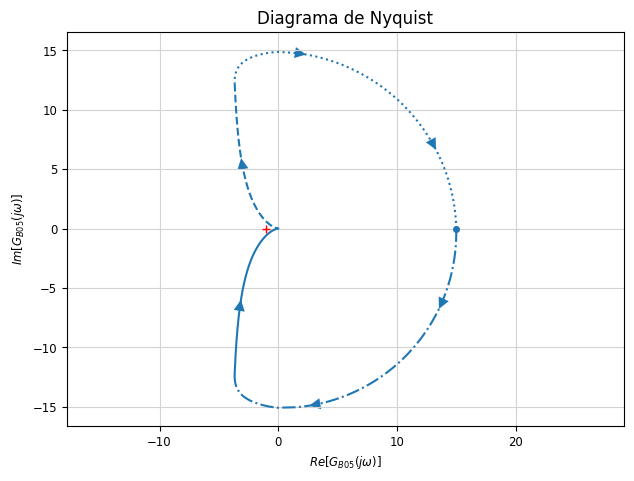

In [ ]:
plt.figure()
ctrl.nyquist_plot(G_B05, title='')
plt.title('Diagrama de Nyquist')
plt.xlabel('$Re[G_{B05}(j\\omega)]$')
plt.ylabel('$Im[G_{B05}(j\\omega)]$')
plt.grid(True)
plt.axis('equal')
plt.show()

##### A partir del criterio de estabilidad de Nyquist, se puede observar que el sistema es estable en lazo cerrado:
- $P = 0$ (cantidad de polos del sistema a lazo abierto que estan en el RHP)
- $N = 0$ (cantidad de vueltas alrededor de $-1+j0$)
- $Z = P - N$ donde $Z$ es la cantidad de polos del sistema a lazo cerrado en el RHP, el cual es $Z = 0$

### Inciso B

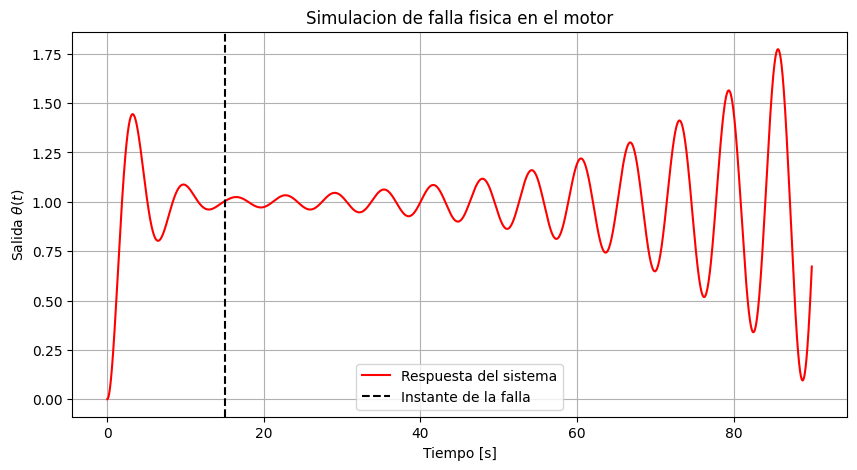

In [ ]:
# Tiempos de simulacion
t1 = np.linspace(0, 15, 1000)
t2 = np.linspace(15, 90, 3000)

# Sistema con B=0.5
sys1 = ctrl.ss(G_B05_closed)
response1 = ctrl.forced_response(sys1, T=t1, U=1)
t_out1 = response1.time
y_out1 = response1.outputs
x_out1 = response1.states
x_final_stage1 = x_out1[:, -1]

# Sistema con B=-0.1
sys2 = ctrl.ss(G_B01_closed)
response2 = ctrl.forced_response(sys2, T=t2, U=1, X0=x_final_stage1)
t_out2 = response2.time
y_out2 = response2.outputs
x_out2 = response2.states

t_total = np.concatenate([t_out1, t_out2])
y_total = np.concatenate([y_out1, y_out2])

plt.figure(figsize=(10, 5))
plt.plot(t_total, y_total, label='Respuesta del sistema', color='red')
plt.axvline(x=15, color='black', linestyle='--', label='Instante de la falla')
plt.xlabel('Tiempo [s]')
plt.ylabel('Salida $\\theta(t)$')
plt.title('Simulacion de falla fisica en el motor')
plt.grid(True)
plt.legend()
plt.show()

### Inciso C

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


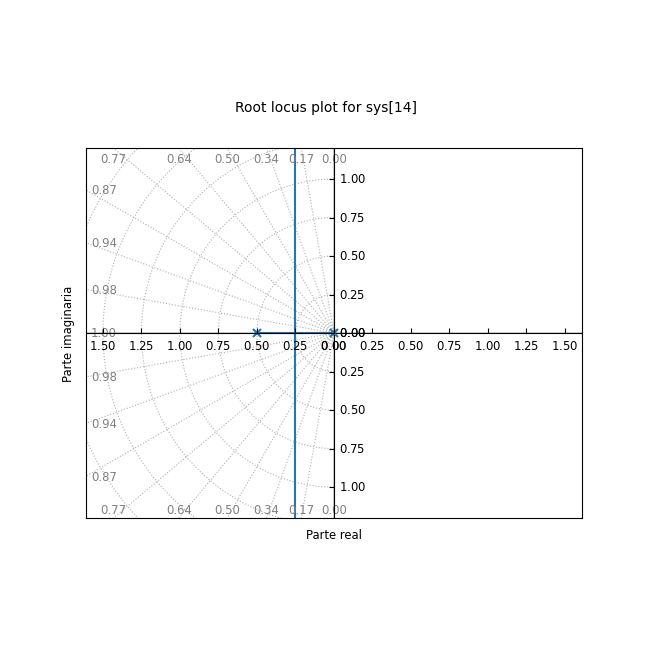

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


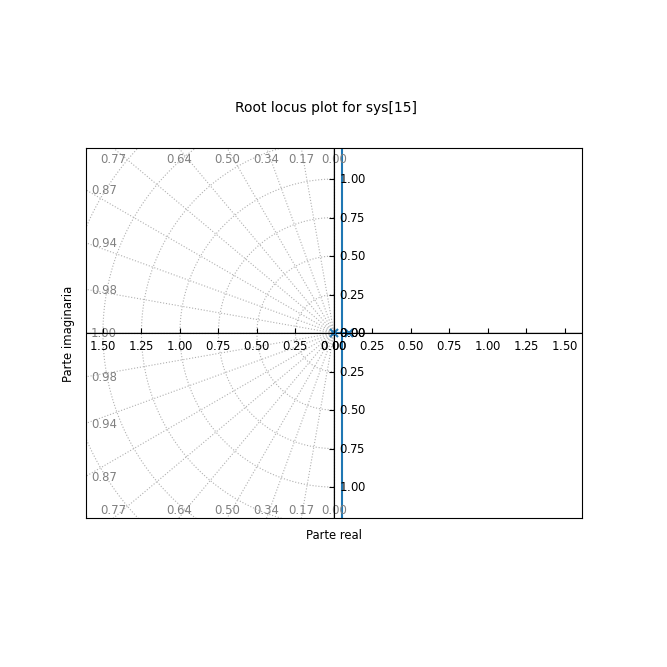

In [18]:
ctrl.root_locus(G_B05)
plt.xlabel('Parte real')
plt.ylabel('Parte imaginaria')
plt.xlim(-1.2, 1.2) 
plt.ylim(-1.2, 1.2)
plt.grid(True)
plt.show()

ctrl.root_locus(G_B01)
plt.xlabel('Parte real')
plt.ylabel('Parte imaginaria')
plt.xlim(-1.2, 1.2) 
plt.ylim(-1.2, 1.2)
plt.grid(True)
plt.show()

##### La estabilidad depende del valor de B: la función de transferencia es $\tfrac{K}{s(Js+B)}=\tfrac{1}{s(s+B)}$, los polos del sistema son $s=0$ y $s=-B$
##### De esta manera:
- Con $B>0$ el polo tiene parte real negativa, por lo que el sistema es estable.
- Con $B<0$ el polo tiene parte real positiva, por lo que el sistema es inestable.
- Con $B=0$ hay doble polo en cero, po rlo que el sistema se vuelve marginalmente estable (oscila).

##### En cuanto a la robustez, frente a un cambio pequeño que cruce el eje imaginario destruye el control del sistema. Además, incluso si $B$ se mantiene positivo, el sistema es sensible (si $B$ disminuye aparecen oscilaciones o sobrepicos y si aumenta mucho el sistema se vuelve muy lento)

### Inciso D

##### A partir de los resultados anteriores, el tipo de compensador que se considera adecuado es un compensador en adelanto. Esta elección se debe a que el sistema tiene un polo en el origen ($s=0$) que aporta -90° de fase, y un segundo polo en $s=-B$ el cual aporta de manera distinta a la fase:
- B>0: polo estable, la fase total tiende a -180° pero no la alcanza.
- B=0: polo doble en el origen, con fase constante de -180°, lo que hace que el sistema sea marginalmente estable (oscila).
- B<0: la fase cae por debajo de los -180°, por lo que convierte al sistema en inestable.
##### De esta manera, el compensador en adelanto agregaria fase positiva al sistema en lazo abierto, incrementando el margen de fase, permitiendo que el sistema soporte la falla.

## Parte B

#### Inciso A

##### Para este inciso, se usó un compensador en adelanto de la forma $C(s) = k\tfrac{s+1}{s+k}$, el cual es un compensador normalizado que no genera cambios bruscos en la ganancia de estado estacionario, esto se puede ver con $lim_{s\rightarrow 0} C(s) = lim_{s\rightarrow 0} k\tfrac{s+1}{s+k} = 1$.
##### Como un compensador en adelanto tiene el cero a la derecha del polo y este compensador tiene un cero en $s = -1$ y un polo en $s = -k$, entonces $k > 1$. Para el diseño del compensador, se varía el valor de k, desde 1.1, hasta llegar al valor del margen de fase deseado.
##### Este tipo de compensador se puede usar porque permite aumentar el margen de fase del sistema, permitiendo la mejora en la estabilidad frente a variaciones de B. Introduce fase positiva, lo que ayuda a compensar el efecto de los polos de la planta que aportan fase negativa. Además, al estar normalizado no modifica el comportamiento en régimen permanente ni el error de estado estacionario.

In [62]:
def compensador(z):
    num = [z, z]
    den = [1, z]
    return ctrl.tf(num, den)

In [64]:
z_values = np.linspace(1.1, 50, 100000)
objetivos = [35, 50, 60]
z_encontrados = [None, None, None]

for z in z_values:
    C = compensador(z)
    L = C * G_B05
    _, pm, _, _ = ctrl.margin(L)

    for i, objetivo in enumerate(objetivos):
        if z_encontrados[i] is None and pm >= objetivo:
            z_encontrados[i] = z

    if all(v is not None for v in z_encontrados):
        break

print('Resultados:')
for objetivo, z in zip(objetivos, z_encontrados):
    print(f'Para MF={objetivo}°: z={z}')

Resultados:
Para MF=35°: z=1.360639606396064
Para MF=50°: z=2.746479464794648
Para MF=60°: z=5.2399153991539915


#### Inciso B

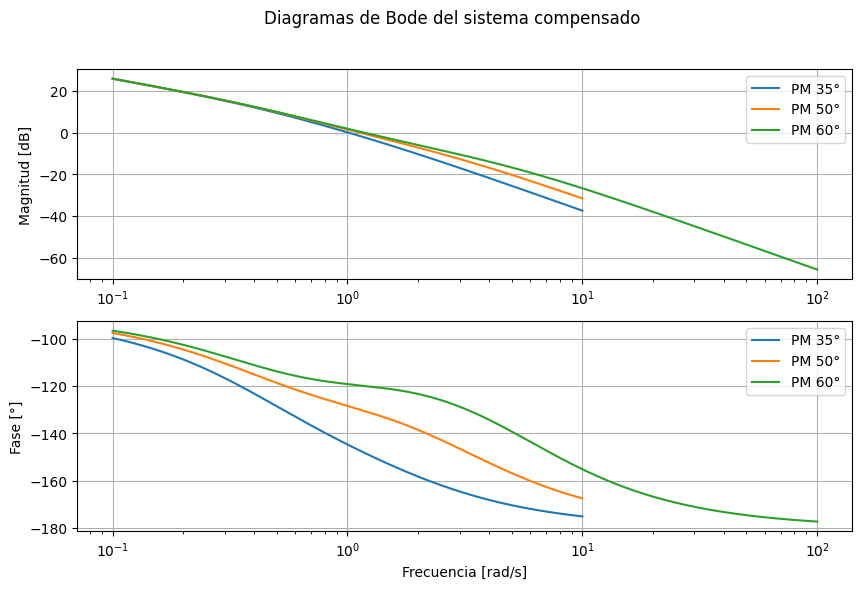

In [74]:
plt.figure(figsize=(10, 6))

labels = ['35°', '50°', '60°']

for z, label in zip(z_encontrados, labels):
    C = compensador(z)
    L = C * G_B05
    
    mag, phase, omega = ctrl.frequency_response(L)
    
    plt.subplot(2, 1, 1)
    plt.semilogx(omega, 20*np.log10(mag), label=f'PM {label}')
    plt.ylabel('Magnitud [dB]')
    plt.grid(True)

    plt.subplot(2, 1, 2)
    plt.semilogx(omega, phase * 180/np.pi, label=f'PM {label}')
    plt.ylabel('Fase [°]')
    plt.xlabel('Frecuencia [rad/s]')
    plt.grid(True)

plt.subplot(2, 1, 1)
plt.legend()

plt.subplot(2, 1, 2)
plt.legend()

plt.suptitle('Diagramas de Bode del sistema compensado')
plt.show()

In [79]:
for z, label in zip(z_encontrados, labels):
    C = compensador(z)
    L = C * G_B05
    
    dc_gain = ctrl.dcgain(C)
    gm, pm, wg, wp = ctrl.margin(L)
    
    print(f"Compensador {label}:")
    print(f"- Margen de fase = {pm:.2f}°")
    print(f"- Frecuencia de cruce = {wp:.2f} rad/s")
    print(f"- Compensador: Ganancia DC = {dc_gain}\n")

Compensador 35°:
- Margen de fase = 35.00°
- Frecuencia de cruce = 1.01 rad/s
- Compensador: Ganancia DC = 1.0

Compensador 50°:
- Margen de fase = 50.00°
- Frecuencia de cruce = 1.13 rad/s
- Compensador: Ganancia DC = 1.0

Compensador 60°:
- Margen de fase = 60.00°
- Frecuencia de cruce = 1.18 rad/s
- Compensador: Ganancia DC = 1.0



#### Inciso C

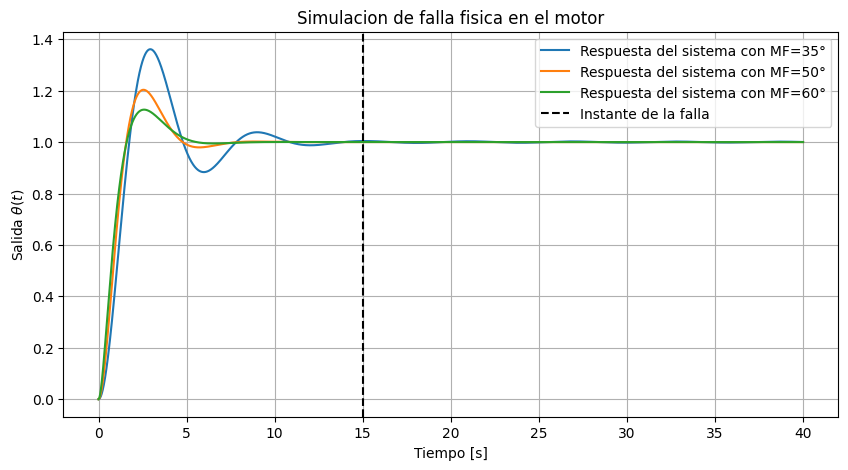

In [111]:
t1 = np.linspace(0, 15, 1000)
t2 = np.linspace(15, 40, 3000)

plt.figure(figsize=(10, 5))

for z, label in zip(z_encontrados, labels):
    C = compensador(z)
    L_B05 = C * G_B05
    L_B01 = C * G_B01
    L_B05_closed = ctrl.feedback(L_B05, 1)
    L_B01_closed = ctrl.feedback(L_B01, 1)

    # Sistema con B=0.5
    sys1 = ctrl.ss(L_B05_closed)
    response1 = ctrl.forced_response(sys1, T=t1, U=1)
    t_out1 = response1.time
    y_out1 = response1.outputs
    x_out1 = response1.states
    x_final_stage1 = x_out1[:, -1]

    # Sistema con B=-0.1
    sys2 = ctrl.ss(L_B01_closed)
    response2 = ctrl.forced_response(sys2, T=t2, U=1, X0=x_final_stage1)
    t_out2 = response2.time
    y_out2 = response2.outputs
    x_out2 = response2.states

    t_total = np.concatenate([t_out1, t_out2])
    y_total = np.concatenate([y_out1, y_out2])

    plt.plot(t_total, y_total, label=f'Respuesta del sistema con MF={label}')
 
plt.axvline(x=15, color='black', linestyle='--', label='Instante de la falla')
plt.xlabel('Tiempo [s]')
plt.ylabel('Salida $\\theta(t)$')
plt.title('Simulacion de falla fisica en el motor')
plt.grid(True)
plt.legend()
plt.show()

##### <span style='color:red'>Analice los tiempos de establecimiento para cada caso. ¿A qué tipo de sistema se parece cada vez más a medida que se incrementa el MF?</span>

#### <span style='color:red'>Inciso D</span>
#### <span style='color:red'>1. Analice el Diagrama de Nyquist del sistema compensado y explique cómo el compensador ”aleja” la curva del punto crítico (−1,0), garantizando robustez ante la degradación física del motor.</span>
#### <span style='color:red'>2. ¿Qué desventajas observa al seguir incrementando el MF de esta forma?</span>